In [1]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import aplpy

import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import glob
from tqdm.notebook import tqdm

sys.path.append("process_tools/")
from cut_resize_tools import *
from Astronomy import *

In [2]:
fits_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/FGN_01500+0000_2x2_12CO_v1.00_cube.fits"
integ_hdu = fits.open("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/FUGIN/mom0/FGN_01500+0000_2x2_12CO_v1.00_cube.pk_vsmooth_2.0_xysmooth_2.0_thresh_700.0_sigma_3.0_mom0.fits")[0]

w_high = WCS(fits_path)
hdu = fits.open(fits_path)[0]
wcs = WCS(integ_hdu.header)

raw_d = hdu.data
header = hdu.header

In [3]:
hdu.data.shape

(462, 848, 848)

In [4]:
vsmooth = 5
thresh = 10
sigma = 1
sch_rms = 10
ech_rms = 50
sch_ii = 160
ech_ii = 220
percentile = 99.997
width_half = 30
sigma_multiply = None
# width = 60

cut_size_list = np.array([100, 50, 25])
integrate_layer_num = 30
obj_size = 100
maximum_mode = "percentile"

In [5]:
catalogue_path = '/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Bubble_Catalogue/infer_catalogue_all.csv' # 提供されたCSVファイル
catalogue_data = pd.read_csv(catalogue_path)

In [6]:
fits_path_all = glob.glob("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/*.fits")
fits_path_all.sort()
fits_path_all = fits_path_all[:4]

In [7]:
babble_region_galactic = [] # 銀河座標を格納するリスト
for index, row in catalogue_data.iterrows():
    glon_min = row['ra_min'] # カタログにはなぜかra, decの場所にglon, glatの座標が入っている
    glon_max = row['ra_max']
    glat_min = row['dec_min']
    glat_max = row['dec_max']

    # (l, b) のリストを作成
    babble_region_galactic.append([
        [glon_min, glat_min], # 0: L_min, B_min
        [glon_max, glat_min], # 1: L_max, B_min
        [glon_min, glat_max], # 2: L_min, B_max
        [glon_max, glat_max]  # 3: L_max, B_max
    ])
print(f"babble_region_galactic len: {len(babble_region_galactic)}")

# --- babble_region_pix への変換 (修正) ---
# ループ元を babble_region_galactic に変更
babble_region_pix = []
for i in range(len(babble_region_galactic)):
    babble_region = babble_region_galactic[i] # 銀河座標のバブル領域
    region_list = []
    for j, world_coords_list in enumerate(babble_region):
        world_coords_list = [babble_region[j]] # [L, B] のリスト

        # WCS変換。世界座標 (L, B) をピクセル座標に変換
        # origin=0 でPythonの0-based indexに対応
        region_pix_result = wcs.wcs_world2pix(world_coords_list, 0)

        # 変換結果の形状と要素数をチェックする
        if len(region_pix_result) > 0 and len(region_pix_result[0]) == 2:
            region_list.append(region_pix_result[0]) # 期待通り [x, y] を追加
        else:
            print(f"警告: bubble_num={i}, point_idx={j} のWCS変換結果が不正です: {region_pix_result}. NaNで埋めます。")
            region_list.append([np.nan, np.nan]) # NaNで埋めて、後で除外されるようにする

    babble_region_pix.append(region_list)
print(f"babble_region_pix len: {len(babble_region_pix)}")

babble_region_galactic len: 3006
babble_region_pix len: 3006


In [8]:
cutting_ratio = 2
cutting_data_dic = {}
data_to_cut = raw_d.copy() # raw_d からのコピー

for bubble_num in range(len(babble_region_pix)):
    all_x_coords = [p[0] for p in babble_region_pix[bubble_num]]
    all_y_coords = [p[1] for p in babble_region_pix[bubble_num]]

    # ピクセル座標の最小値と最大値を取得
    # np.min と np.max を使うことで、座標の順序に関わらず正しい矩形領域の境界を取得
    # これにより、x_max_pix < x_min_pix のような逆転を防ぎ、スライス範囲が巨大になるのを防ぐ
    x_min_pix = int(np.floor(np.min(all_x_coords)))
    x_max_pix = int(np.ceil(np.max(all_x_coords)))
    y_min_pix = int(np.floor(np.min(all_y_coords)))
    y_max_pix = int(np.ceil(np.max(all_y_coords)))

    x_center = (x_min_pix + x_max_pix) // 2 
    y_center = (y_min_pix + y_max_pix) // 2
    
    x_range = (x_max_pix - x_min_pix) // 2 * cutting_ratio
    y_range = (y_max_pix - y_min_pix) // 2 * cutting_ratio

    x_min_pix = int(x_center - x_range)
    x_max_pix = int(x_center + x_range)
    y_min_pix = int(y_center - y_range)
    y_max_pix = int(y_center + y_range)

    # 切り出し実行
    # ここでは、np.clip を使用せず、NumPyのスライスが範囲外を0で自動パディングする動作に任せる
    # ただし、x_min_pix/y_min_pix が負になったり、x_max_pix/y_max_pix が大きくなりすぎたりすると、
    # 巨大な配列が生成される可能性がある点に注意（メモリ消費、処理時間）
    cutting_data = data_to_cut[:, y_min_pix:y_max_pix, x_min_pix:x_max_pix]
    pix_cood = (x_min_pix, x_max_pix, y_min_pix, y_max_pix)
    cutting_data_dic[pix_cood] = cutting_data

    # デバッグ用に切り出したデータの形状と範囲を表示してみる
    # print(f"Bubble {bubble_num}: X range [{x_min_pix}, {x_max_pix}], Y range [{y_min_pix}, {y_max_pix}], Shape: {cutting_data.shape}")

In [9]:
deleted_indices = []
filtered_list = [
    data for idx, data in enumerate(cutting_data_dic.items()) 
    if not np.all((data[1] == 0) | np.isnan(data[1]))
    or deleted_indices.append(idx)  # 削除されたインデックスを記録
]

# 削除されたインデックスを表示
print("削除されたデータのインデックス:", deleted_indices)
print("削除された数: ", len(deleted_indices))
print("残ったデータ数: ",len(filtered_list))

削除されたデータのインデックス: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 21

In [10]:
# remove_list = [0, 5, 8, 9, 10, 12, 17, 19, 21, 34]
# filtered_list = [data for i, data in enumerate(filtered_list) if i not in remove_list]

IndexError: index 35 is out of bounds for axis 0 with size 35

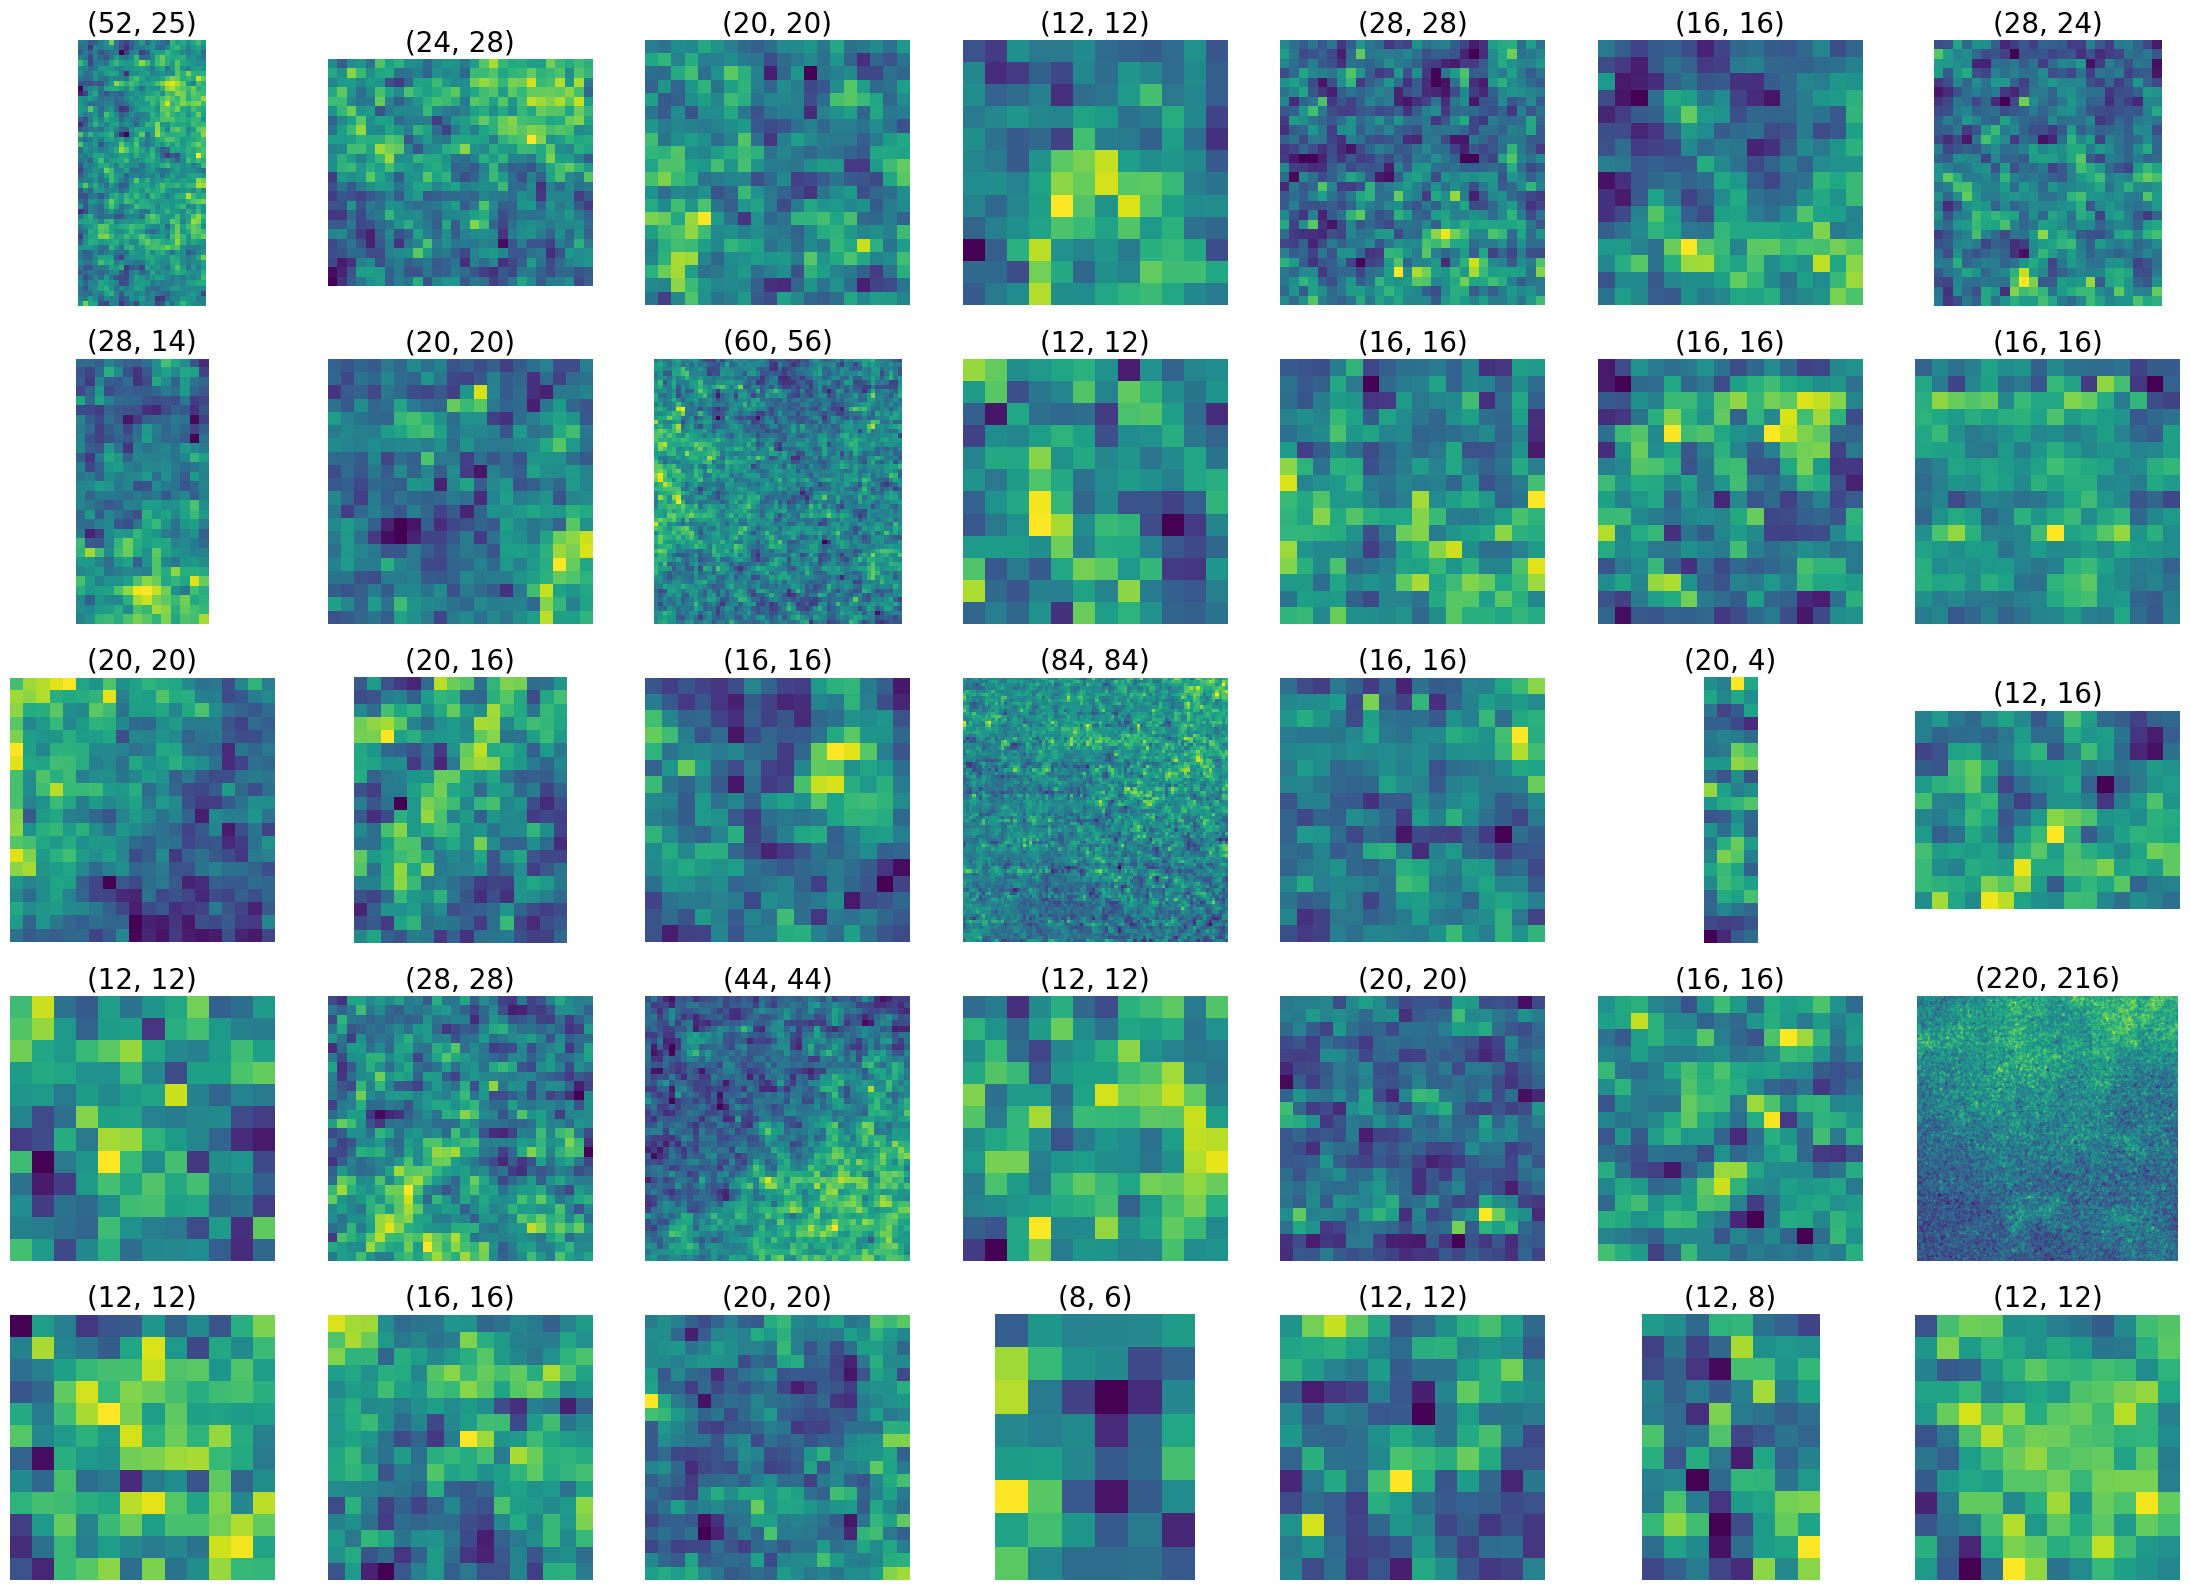

In [11]:
fig, axes = plt.subplots(5, 7, figsize=(4*7, 4*5))
axes = axes.flatten()  # 3x10の軸を1次元配列に変換

for n in range(len(filtered_list)):  # 30個の画像を配置
    data = filtered_list[n][1]
    integ_data = np.nansum(data, axis=0)
    
    axes[n].imshow(integ_data)
    axes[n].axis("off")
    axes[n].set_title((filtered_list[n][1].shape[1], filtered_list[n][1].shape[2]), fontsize=20)

plt.tight_layout()
# plt.savefig("bubbles_zeroing_integ_shape_3.png")
plt.show()

In [12]:
all_map = raw_d.copy()

In [13]:
for pdu in filtered_list:
    pdu = pdu[0]
    x_min, x_max, y_min, y_max = pdu[0], pdu[1], pdu[2], pdu[3]

    # 1. 対象領域をスライスで取得
    region = all_map[:, y_min:y_max, x_min:x_max]
    
    # 2. 領域内でNaNではない要素のマスクを作成
    # np.isnan(region) は NaN の位置が True になる
    # ~ で論理反転させ、NaNで「ない」位置を True にする
    not_nan_mask = ~np.isnan(region)
    
    # 3. マスクがTrueの位置（NaNでない要素）だけを0にする
    region[not_nan_mask] = np.nan

In [14]:
all_map.shape

(462, 848, 848)

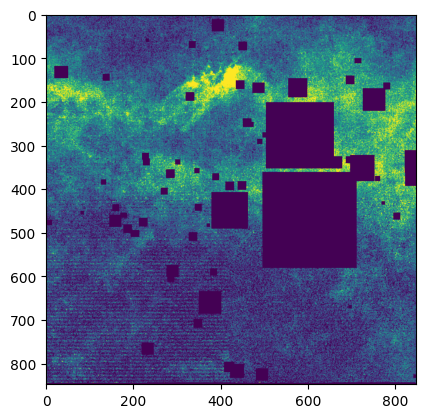

In [15]:
plt.imshow(np.nansum(all_map, axis=0), vmin=0, vmax=500)

In [16]:
a = [1, 1, 1]
b = [2, 2, 2]
a += b
print(a)

[1, 1, 1, 2, 2, 2]


In [18]:
processed_all_list = []
for pix in cut_size_list:
    print(f"Processing data clipped to {pix} pixels...")

    # Step1: スライス
    cut_data = slide(all_map, pix+4, 4)
    print(f"Number of data clipped to {pix} pixels: {len(cut_data)}")

    cut_data = remove_nan(cut_data)
    print(f"Number of data after deletion: {len(cut_data)}")

    # Step2: 並列前処理
    processed_list = parallel_processing(
                                        function=process_data_segment_center_ver, 
                                        target=cut_data,
                                        vsmooth=vsmooth,
                                        sch_rms=sch_rms, 
                                        ech_rms=ech_rms,
                                        sigma=sigma, 
                                        thresh=thresh, 
                                        width=width_half,
                                        integrate_layer_num=integrate_layer_num
                                        )
    processed_all_list += processed_list

Processing data clipped to 100 pixels...
Number of data clipped to 100 pixels: 841
Number of data after deletion: 196
Processing data clipped to 50 pixels...
Number of data clipped to 50 pixels: 3844
Number of data after deletion: 1970
Processing data clipped to 25 pixels...
Number of data clipped to 25 pixels: 13924
Number of data after deletion: 9466


In [19]:
len(processed_all_list)

11632

In [20]:
max_thresh = maximum_value_determination(
                                         mode=maximum_mode, 
                                         data=raw_d, 
                                         vsmooth=vsmooth, 
                                         sch_rms=sch_rms, 
                                         ech_rms=ech_rms, 
                                         sch_ii=sch_ii, 
                                         ech_ii=ech_ii, 
                                         sigma=sigma, 
                                         thresh=thresh, 
                                         integrate_layer_num=integrate_layer_num, 
                                         percentile=percentile
                                        )

======== maximum determination ========
-------- making v_convolution data --------
-------- masking data --------


/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


-------- integrating and xy_convolution --------
percentile value is 106.11


In [21]:
conv_resize_list = []
for _data in tqdm(processed_all_list):
    # _data = select_conv(_data, obj_size, obj_sig)
    _data = gaussian_filter(_data)
    _data = resize(_data, (obj_size, obj_size))
    if maximum_mode in ["percentile", "sigma"]:
        _data = np.clip(_data, a_min=None, a_max=max_thresh)
    conv_resize_list.append(_data)
del processed_all_list

conv_resize_list = normalization_thresh(conv_resize_list, max_thresh)

  0%|          | 0/11632 [00:00<?, ?it/s]

# データ確認

In [22]:
random_num = sorted(np.random.choice(len(conv_resize_list), 20))
print(random_num)

[659, 920, 1365, 1432, 1796, 2595, 2644, 2893, 3797, 5089, 6568, 7284, 8087, 8921, 9333, 9354, 9893, 10679, 10933, 11417]


In [23]:
conv_resize_list[0].shape[0]

30

In [24]:
# fitsのPathからfitsの名前のみを取り出す
fits_name = fits_path.split("/")[-1]
region_name = fits_name.split("_")
region_name = region_name[0] + "_" + region_name[1]
region_dir = "./processed_data/" + region_name
print(region_dir)

./processed_data/FGN_01500+0000


In [ ]:
axes_num = conv_resize_list[0].shape[0]

for index in random_num:
    data = conv_resize_list[index]
    print(data.min())
    print(data.max())
    
    fig, axes = plt.subplots(1, axes_num, figsize=(axes_num*3, 1*4))
    for j, data_segment in enumerate(data):
        axes[j].imshow(data_segment, vmin=0, vmax=1, cmap="jet")
        axes[j].axis("off")
        axes[j].set_title(f"{j+1}ch", fontsize=20, color='red')

    fig.suptitle(f"Data No.{index}, min={data.min():.2f}, max={data.max():.2f}", fontsize=30) 
    plt.tight_layout()
    # plt.savefig(f"{region_name}_random_cannelmap_No{index}.png")
    plt.show()

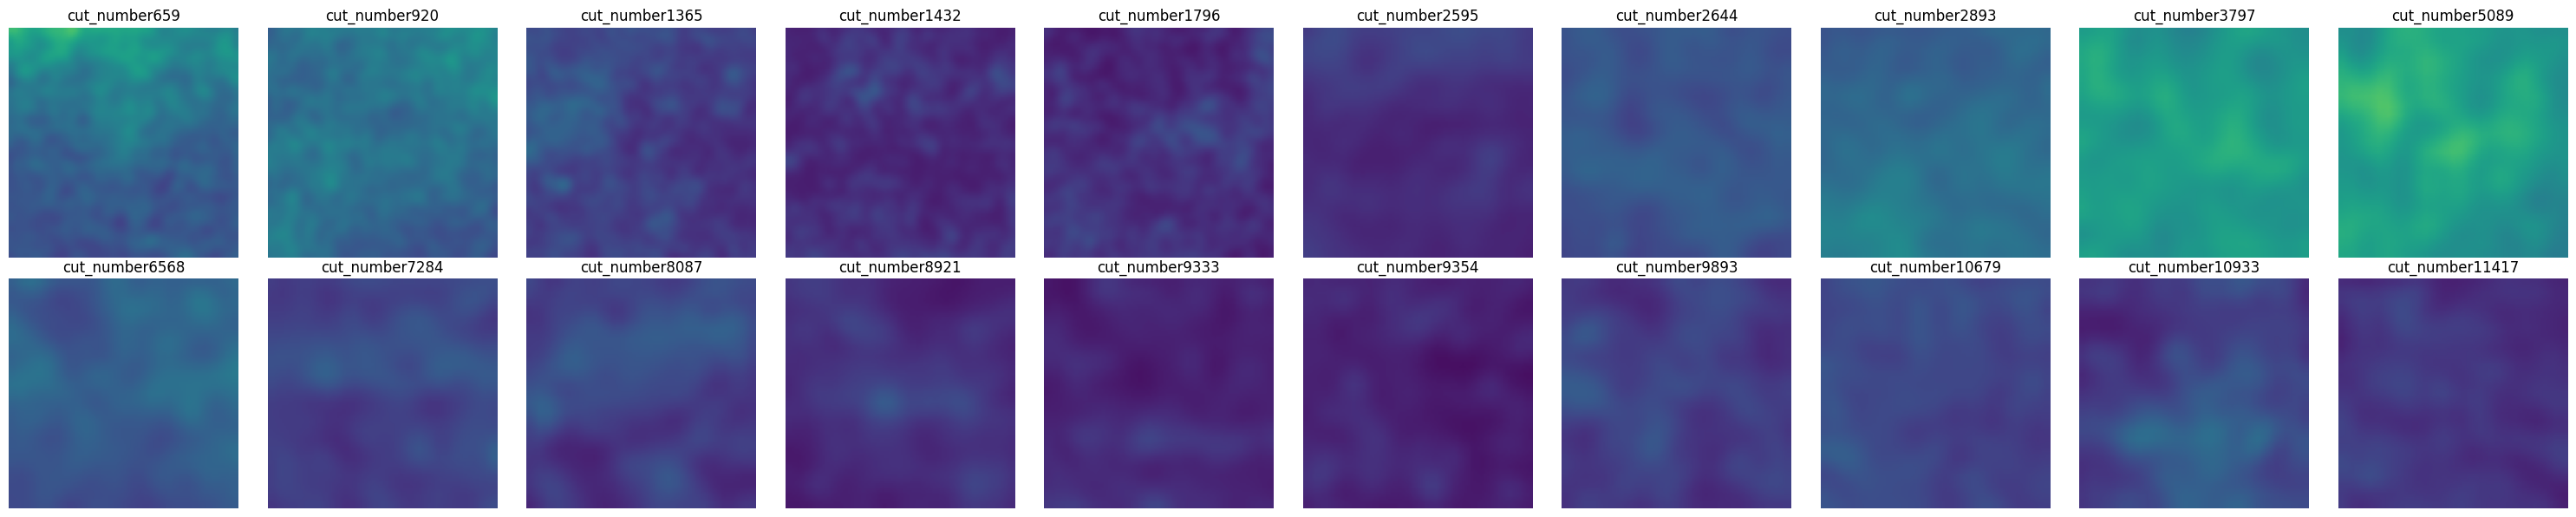

In [27]:
fig, axes = plt.subplots(2, 10, figsize=(3*10, 6))
for i, num in enumerate(random_num):
    axes = axes.flatten()
    data = conv_resize_list[num]
    integ_data = np.nansum(data, axis=0)

    axes[i].imshow(integ_data, cmap="viridis", vmin=0, vmax=5)
    axes[i].axis("off")
    axes[i].set_title(f"cut_number{num}")

plt.tight_layout()
# plt.savefig(f"{region_name}_integrated_random_data.png")
plt.show()

In [ ]:
len(conv_resize_list)

# データ保存

In [ ]:
Path(region_dir).mkdir(parents=True, exist_ok=True)

np.save(f"./processed_data/{region_name}/non_bubble_data", conv_resize_list)